# Проверка корректности критерия 

Статья: https://habr.com/ru/companies/X5Tech/articles/706388/

**Что мы хотим**

1. Для любого $\alpha$: $P(pvalue < \alpha | H_0) \implies F_{pvalue} \text{ равномерна}$
2. $P(pvalue < \alpha | H_1) = 1 - \beta \implies F_{pvalue} \text{ проходит через точку } [\alpha, 1 - \beta]$


- Корректный критерий – это критерий, у которого вероятности ошибок первого и второго рода равны допустимым вероятностям ошибок первого и второго рода соответственно. Проверить можно с помощью Монте-Карло (AA тесты для type I, AB тесты для type II)

- чтобы критерий контролировал вероятность ошибки первого рода для любого уровня значимости, хотим, чтобы p-value при верности нулевой гипотезы было распределено равномерно от 0 до 1

In [9]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

plt.rcParams['figure.dpi'] = 150

In [16]:
alpha = 0.1
beta = 0.2
mu = 2500
std = 800
mde = 100

N = 10000

sample_size = 800

values = stats.norm(loc=mu, scale=std).rvs(N)

def run_synthetic_experiments(values, sample_size, effect=0, n_iter=10000):
    """Проводим синтетические эксперименты, возвращаем список p-value."""
    pvalues = []
    for _ in range(n_iter):
        a, b = np.random.choice(values, size=(2, sample_size,), replace=False)
        b += effect
        pvalue = stats.ttest_ind(a, b).pvalue
        pvalues.append(pvalue)
    return np.array(pvalues)

def print_estimated_errors(pvalues_aa, pvalues_ab, alpha):
    """Оценивает вероятности ошибок."""
    estimated_first_type_error = np.mean(pvalues_aa < alpha)
    estimated_second_type_error = np.mean(pvalues_ab >= alpha)
    ci_first = proportion_confint(np.sum(pvalues_aa < alpha), nobs = len(pvalues_aa), alpha=alpha, method='wilson')
    ci_second = proportion_confint(np.sum(pvalues_ab >= alpha), nobs = len(pvalues_ab), alpha=alpha, method='wilson')
    print(f'оценка вероятности ошибки I рода = {estimated_first_type_error:0.4f}')
    print(f'  доверительный интервал = [{ci_first[0]:0.4f}, {ci_first[1]:0.4f}]')
    print(f'оценка вероятности ошибки II рода = {estimated_second_type_error:0.4f}')
    print(f'  доверительный интервал = [{ci_second[0]:0.4f}, {ci_second[1]:0.4f}]')

pvalues_aa = run_synthetic_experiments(values, sample_size, effect=0)
pvalues_ab = run_synthetic_experiments(values, sample_size, effect=mde)
print_estimated_errors(pvalues_aa, pvalues_ab, alpha)

оценка вероятности ошибки I рода = 0.1030
  доверительный интервал = [0.0981, 0.1081]
оценка вероятности ошибки II рода = 0.1902
  доверительный интервал = [0.1838, 0.1967]


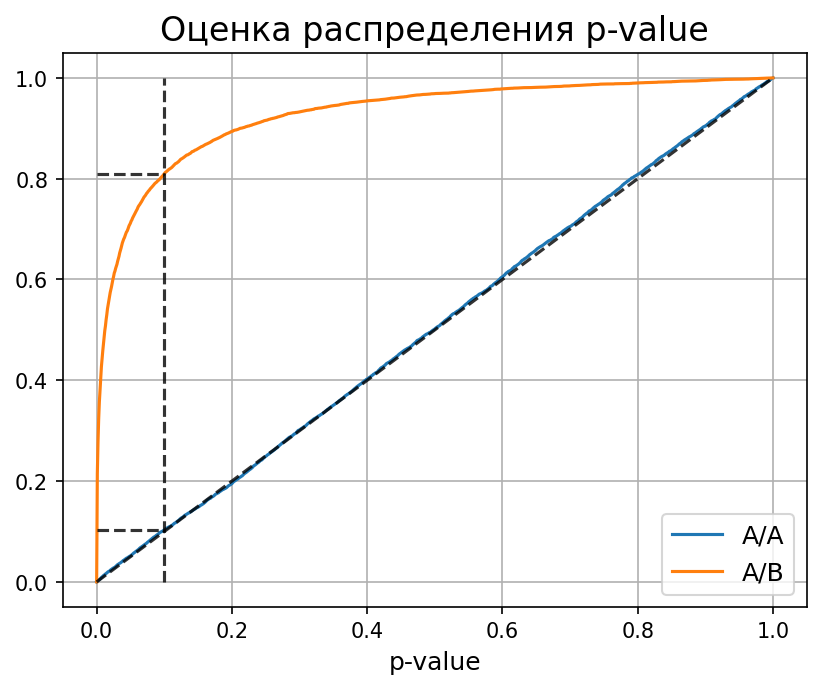

In [17]:
import matplotlib.pyplot as plt

def plot_pvalue_distribution(pvalues_aa, pvalues_ab, alpha, beta):
    """Рисует графики распределения p-value."""
    estimated_first_type_error = np.mean(pvalues_aa < alpha)
    estimated_second_type_error = np.mean(pvalues_ab >= alpha)
    y_one = estimated_first_type_error
    y_two = 1 - estimated_second_type_error
    X = np.linspace(0, 1, 1000)
    Y_aa = [np.mean(pvalues_aa < x) for x in X]
    Y_ab = [np.mean(pvalues_ab < x) for x in X]

    plt.plot(X, Y_aa, label='A/A')
    plt.plot(X, Y_ab, label='A/B')
    plt.plot([alpha, alpha], [0, 1], '--k', alpha=0.8)
    plt.plot([0, alpha], [y_one, y_one], '--k', alpha=0.8)
    plt.plot([0, alpha], [y_two, y_two], '--k', alpha=0.8)
    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)

    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

plot_pvalue_distribution(pvalues_aa, pvalues_ab, alpha, beta)

оценка вероятности ошибки I рода = 0.2250
  доверительный интервал = [0.2040, 0.2474]
оценка вероятности ошибки II рода = 0.0960
  доверительный интервал = [0.0817, 0.1124]


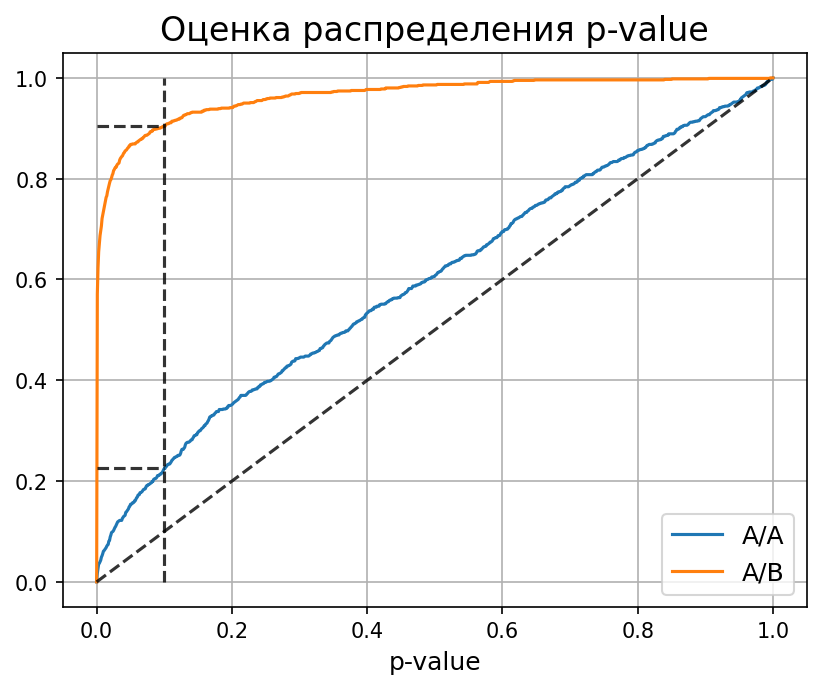

In [ ]:
# Теперь проводим другой тест, распределние будет такое, что вторая неделя дублирует первую
# Тогда значения в выборке будут зависимы друг от друга

# Получим, что оценка Type I сильно завышена (0.2)

def run_synthetic_experiments_two(values, sample_size, effect=0, n_iter=1000):
    """Проводим синтетические эксперименты на двух неделях."""
    pvalues = []
    for _ in range(n_iter):
        a, b = np.random.choice(values, size=(2, sample_size,), replace=False)
        b += effect
        # дублируем данные
        a = np.hstack((a, a,))
        b = np.hstack((b, b,))
        pvalue = stats.ttest_ind(a, b).pvalue
        pvalues.append(pvalue)
    return np.array(pvalues)

pvalues_aa = run_synthetic_experiments_two(values, sample_size)
pvalues_ab = run_synthetic_experiments_two(values, sample_size, effect=mde)
print_estimated_errors(pvalues_aa, pvalues_ab, alpha)
plot_pvalue_distribution(pvalues_aa, pvalues_ab, alpha, beta)